# SCRUM-17: Before-vs-After Data Documentation

**Task:** Document the state of data before and after cleaning to demonstrate data quality improvements.

**Assignee:** Burra Vijay Krishna | **Sprint:** SCRUM Sprint 0

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = os.path.join('..', 'data')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')
YT_DIR = os.path.join(DATA_DIR, 'youtube')
print('Setup complete.')

Setup complete.


## 1. Raw Data Overview (Before Cleaning)

In [2]:
raw_videos = pd.read_csv(os.path.join(YT_DIR, 'videos_snapshot.csv'))
raw_comments = pd.read_csv(os.path.join(YT_DIR, 'comments_snapshot.csv'))

print('=== RAW DATA (Before Cleaning) ===')
print(f'Videos:   {len(raw_videos):,} rows x {len(raw_videos.columns)} cols')
print(f'Comments: {len(raw_comments):,} rows x {len(raw_comments.columns)} cols')
print(f'\nTotal raw records: {len(raw_videos) + len(raw_comments):,}')

=== RAW DATA (Before Cleaning) ===
Videos:   3,600 rows x 10 cols
Comments: 33,217 rows x 8 cols

Total raw records: 36,817


In [3]:
print('=== Raw Videos — Missing Values ===')
print(raw_videos.isnull().sum())
print()
print('=== Raw Comments — Missing Values ===')
print(raw_comments.isnull().sum())

=== Raw Videos — Missing Values ===
snapshot_date     0
product_id        0
query_version     0
video_id          0
title             0
channel_id        0
published_at      0
view_count        0
like_count       86
comment_count     4
dtype: int64

=== Raw Comments — Missing Values ===
snapshot_date    0
product_id       0
query_version    0
video_id         0
comment_id       0
text             2
like_count       0
published_at     0
dtype: int64


## 2. Cleaned Data Overview (After Cleaning)

In [4]:
clean_videos = pd.read_csv(os.path.join(PROCESSED_DIR, 'youtube_videos_clean.csv'))
clean_comments = pd.read_csv(os.path.join(PROCESSED_DIR, 'youtube_comments_clean.csv'))

print('=== CLEANED DATA (After Cleaning) ===')
print(f'Videos:   {len(clean_videos):,} rows x {len(clean_videos.columns)} cols')
print(f'Comments: {len(clean_comments):,} rows x {len(clean_comments.columns)} cols')
print(f'\nTotal clean records: {len(clean_videos) + len(clean_comments):,}')

=== CLEANED DATA (After Cleaning) ===
Videos:   3,500 rows x 10 cols
Comments: 32,215 rows x 10 cols

Total clean records: 35,715


## 3. Before vs After — Comparison Table

In [5]:
comparison = pd.DataFrame([
    {'Table': 'videos', 'Before': len(raw_videos), 'After': len(clean_videos),
     'Dropped': len(raw_videos) - len(clean_videos),
     'Drop%': round((len(raw_videos) - len(clean_videos)) / len(raw_videos) * 100, 1)},
    {'Table': 'comments', 'Before': len(raw_comments), 'After': len(clean_comments),
     'Dropped': len(raw_comments) - len(clean_comments),
     'Drop%': round((len(raw_comments) - len(clean_comments)) / len(raw_comments) * 100, 1)},
])

print('=== BEFORE vs AFTER CLEANING ===')
print(comparison.to_string(index=False))
print(f'\nTotal: {comparison["Before"].sum():,} -> {comparison["After"].sum():,} '
      f'(dropped {comparison["Dropped"].sum():,}, '
      f'{comparison["Dropped"].sum()/comparison["Before"].sum()*100:.1f}%)')

=== BEFORE vs AFTER CLEANING ===
   Table  Before  After  Dropped  Drop%
  videos    3600   3500      100    2.8
comments   33217  32215     1002    3.0

Total: 36,817 -> 35,715 (dropped 1,102, 3.0%)


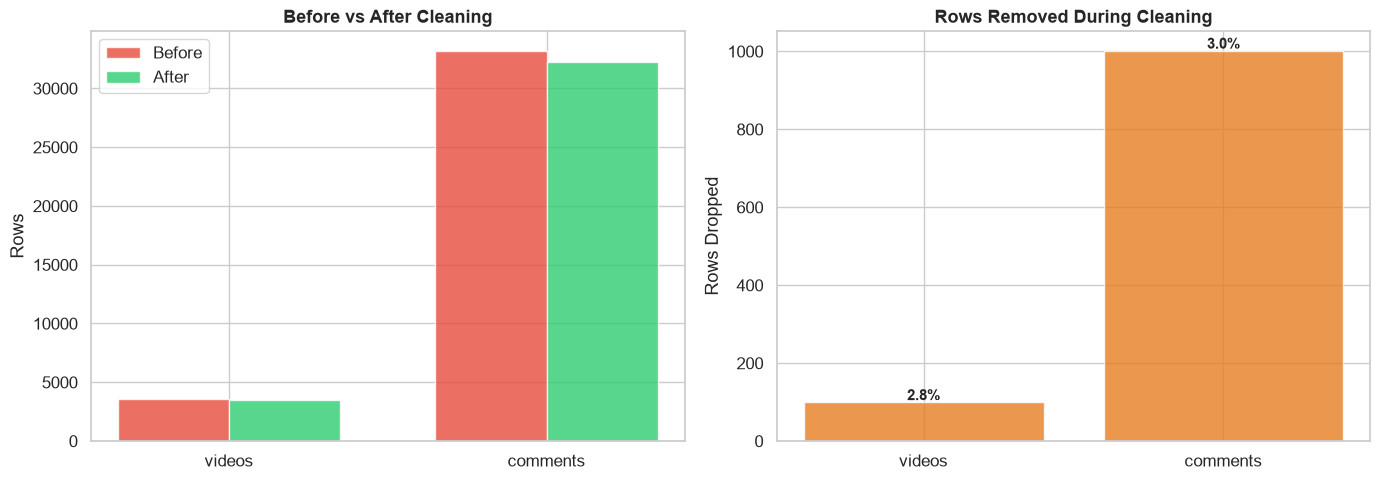

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(comparison))
w = 0.35
axes[0].bar([i - w/2 for i in x], comparison['Before'], w, label='Before', color='#e74c3c', alpha=0.8)
axes[0].bar([i + w/2 for i in x], comparison['After'],  w, label='After',  color='#2ecc71', alpha=0.8)
axes[0].set_ylabel('Rows')
axes[0].set_title('Before vs After Cleaning', fontsize=13, fontweight='bold')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(comparison['Table'])
axes[0].legend()

bars = axes[1].bar(comparison['Table'], comparison['Dropped'], color='#e67e22', alpha=0.8)
axes[1].set_ylabel('Rows Dropped')
axes[1].set_title('Rows Removed During Cleaning', fontsize=13, fontweight='bold')
for bar, pct in zip(bars, comparison['Drop%']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{pct}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig("../docs/before_after_cleaning.png", bbox_inches="tight", dpi=150)
plt.show()

## 4. Cleaning Report Details

In [7]:
cleaning = pd.read_csv(os.path.join(PROCESSED_DIR, 'cleaning_report_youtube.csv'))

impactful = cleaning[
    (cleaning['rows_dropped'].fillna(0).astype(float) > 0) |
    (cleaning['detail'].str.contains('changed|excluded|flagged', case=False, na=False))
]

print('=== Cleaning Steps That Modified Data ===')
print()
for _, row in impactful.iterrows():
    d = row['rows_dropped']
    ds = f', dropped {int(float(d))}' if pd.notna(d) and float(d) > 0 else ''
    print(f'[{row["table"]}] {row["step"]}{ds}')
    print(f'  -> {row["detail"]}')
    print()

=== Cleaning Steps That Modified Data ===

[videos] select_active_query, dropped 100
  -> excluded rows not collected with the active registry's query: P044 v2: 50 (active is v1); P057 v1: 50 (active is v2)

[videos] clean_title
  -> 199 value(s) changed: HTML entities decoded, tags stripped, whitespace collapsed

[videos] output, dropped 100
  -> outliers kept; rows sorted by key

[comments] select_active_query, dropped 1000
  -> excluded rows not collected with the active registry's query: P044 v2: 500 (active is v1); P057 v1: 500 (active is v2)

[comments] clean_text
  -> 3433 value(s) changed: HTML entities decoded, tags stripped, whitespace collapsed

[comments] drop_empty_text, dropped 2
  -> comments empty after text cleaning

[comments] flag_language
  -> flagged, not dropped: is_emoji_only=395, likely_non_english=934

[comments] output, dropped 1002
  -> outliers kept; rows sorted by key

[product_daily] select_active_query, dropped 2
  -> excluded rows not collected with the 

## 5. Missing Values — Before vs After

In [8]:
missing = cleaning[cleaning['step'] == 'missing_values'].copy()
missing = missing[missing['missing_before'].fillna(0).astype(float) > 0]
if len(missing) > 0:
    print('=== Columns with Missing Values ===')
    for _, row in missing.iterrows():
        print(f'[{row["table"]}] {row["column"]}: '
              f'{int(float(row["missing_before"]))} before -> '
              f'{int(float(row["missing_after"]))} after')
else:
    print('No columns had missing values.')

=== Columns with Missing Values ===
[videos] like_count: 86 before -> 85 after
[videos] comment_count: 4 before -> 4 after
[comments] text: 2 before -> 0 after


## 6. Comment Quality Flags

In [9]:
if 'is_emoji_only' in clean_comments.columns:
    emoji_only = clean_comments['is_emoji_only'].sum()
    non_english = clean_comments['likely_non_english'].sum()
    print(f'Emoji-only comments (flagged, kept): {emoji_only}')
    print(f'Likely non-English comments (flagged, kept): {non_english}')
    print(f'Total comments retained: {len(clean_comments)}')
    print()
    print('Note: Flagged comments are KEPT in the dataset, not removed.')
    print('This preserves data for multilingual sentiment analysis.')
else:
    print(f'Clean comments: {len(clean_comments)} rows')
    print('No language flags in this version.')

Emoji-only comments (flagged, kept): 395
Likely non-English comments (flagged, kept): 934
Total comments retained: 32215

Note: Flagged comments are KEPT in the dataset, not removed.
This preserves data for multilingual sentiment analysis.


## 7. On-Target Share — Data Quality Metric

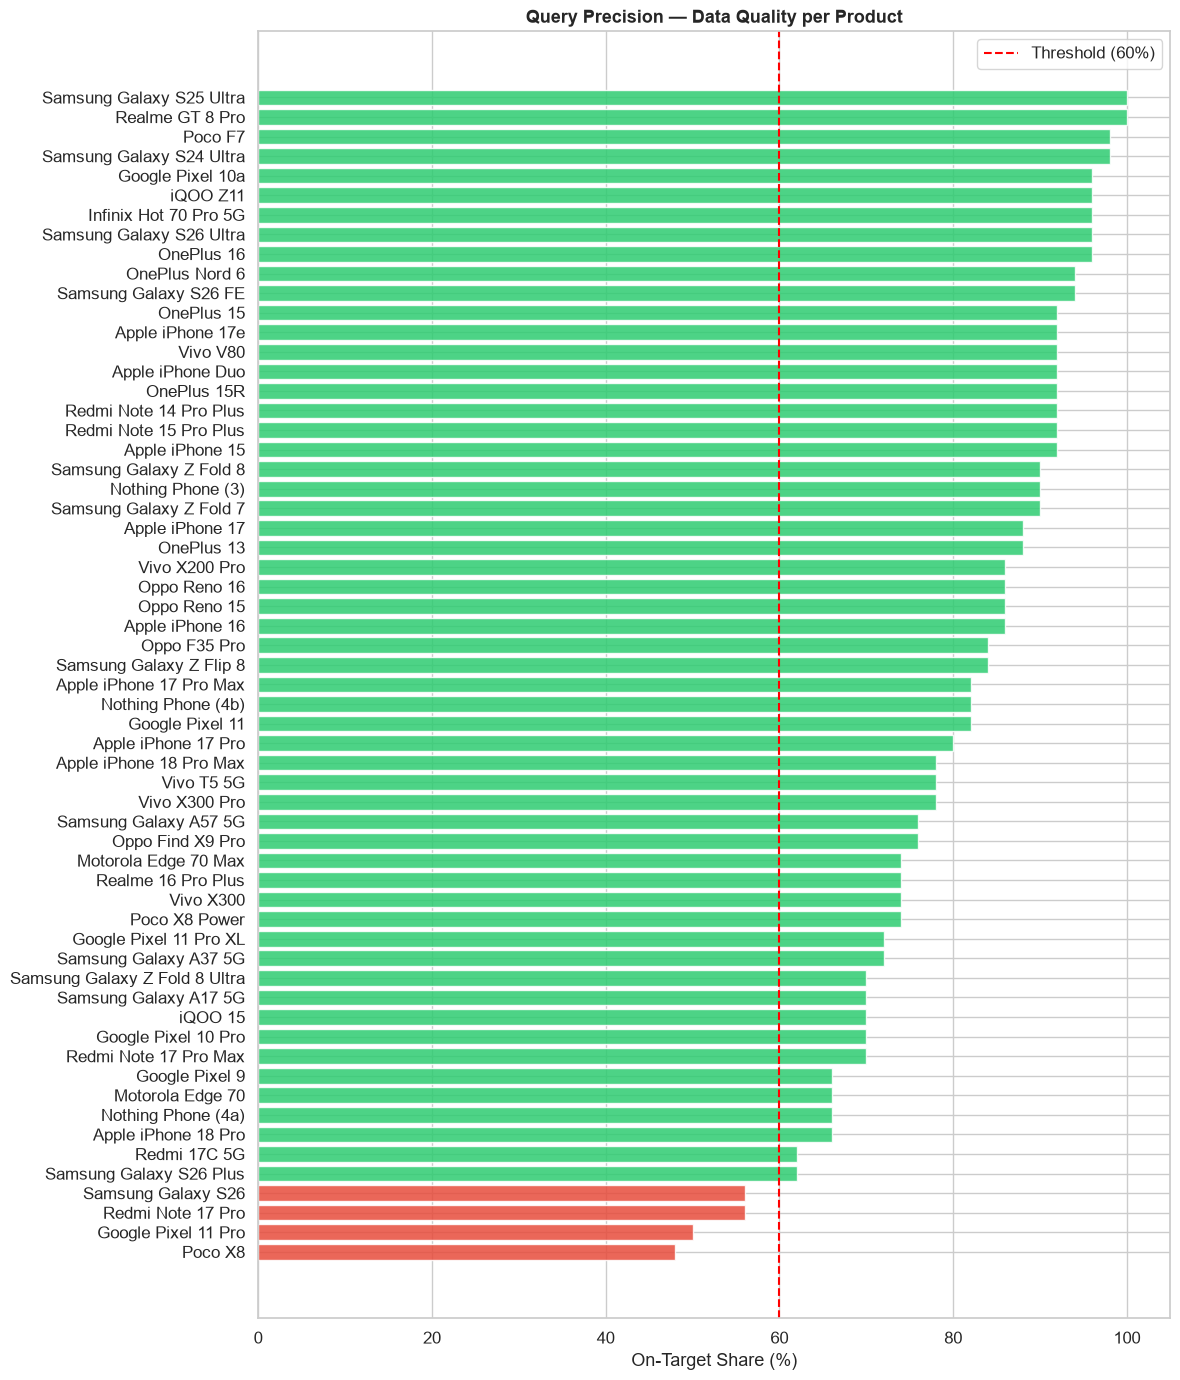


Flagged products (low on-target share): ['Poco X8', 'Google Pixel 11 Pro', 'Redmi Note 17 Pro', 'Samsung Galaxy S26']
These products have noisy queries — sibling model videos dominate results.


In [10]:
report = pd.read_csv(os.path.join(PROCESSED_DIR, 'full_report.csv'))

fig, ax = plt.subplots(figsize=(12, 14))
s = report.sort_values('on_target_share', ascending=True)
bc = ['#e74c3c' if x else '#2ecc71' for x in s['low_on_target_share']]
ax.barh(s['product_name'], s['on_target_share'] * 100, color=bc, alpha=0.85)
ax.axvline(x=60, color='red', linestyle='--', linewidth=1.5, label='Threshold (60%)')
ax.set_xlabel('On-Target Share (%)')
ax.set_title('Query Precision — Data Quality per Product', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig("../docs/on_target_share.png", bbox_inches="tight", dpi=150)
plt.show()

flagged = s[s['low_on_target_share'] == True]
if len(flagged) > 0:
    print(f'\nFlagged products (low on-target share): {flagged["product_name"].tolist()}')
    print('These products have noisy queries — sibling model videos dominate results.')

In [11]:
print('=== SCRUM-17 COMPLETE ===')
print('Before-vs-After data documentation completed.')
print('All cleaning steps documented with evidence.')

=== SCRUM-17 COMPLETE ===
Before-vs-After data documentation completed.
All cleaning steps documented with evidence.
